In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.preprocessing import LabelEncoder, StandardScaler


pd.set_option('display.max_columns', None)

print("Libraries loaded successfully")

Libraries loaded successfully


Dataset Shape: (100000, 47)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,9627.00,374.0,1457.00,883.202217,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,567.00,54.0,54.00,54.000000,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.99,0.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,572.51,54.0,59.51,54.753345,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,6216.00,592.0,592.00,592.000000,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,567.00,54.0,54.00,54.000000,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


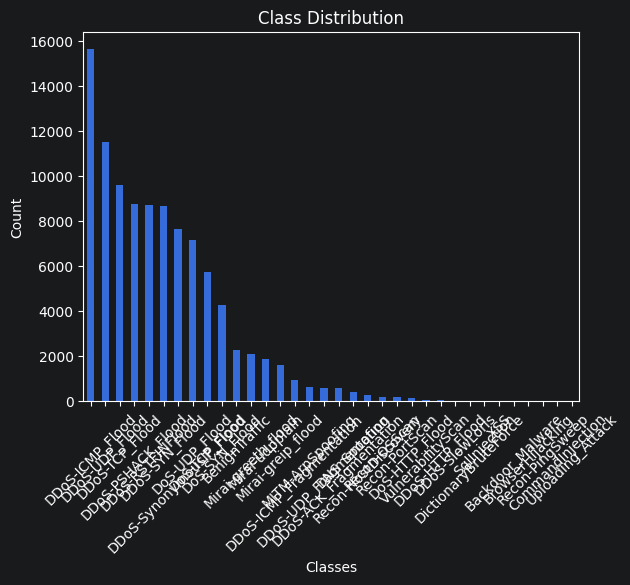

In [2]:

train_path = "CICIOT23/train/train.csv"

df = pd.read_csv(train_path, nrows=100000)

print("Dataset Shape:", df.shape)
display(df.head())

target = "label"  # change if needed

class_counts = df[target].value_counts()

plt.figure()
class_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

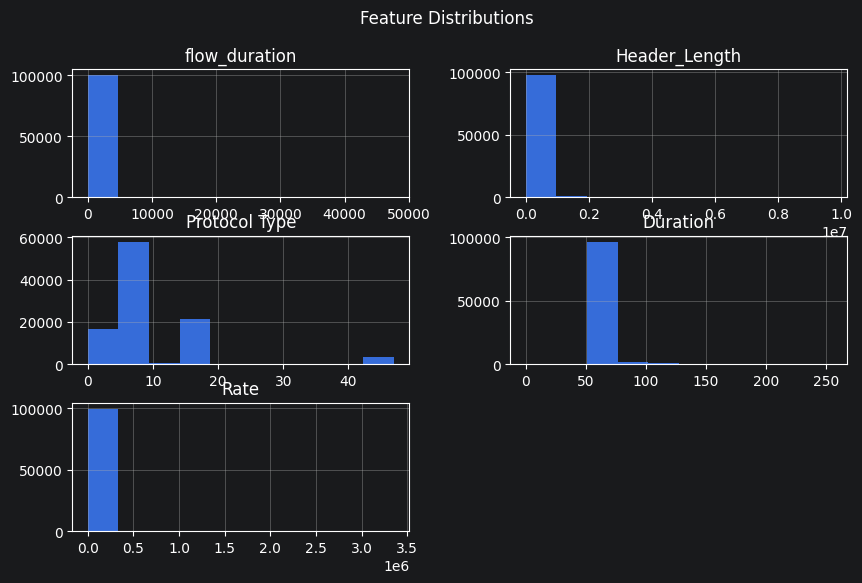

In [3]:
selected_features = df.columns[:5]  # first 5 features

df[selected_features].hist(figsize=(10, 6))

plt.suptitle("Feature Distributions")
plt.show()

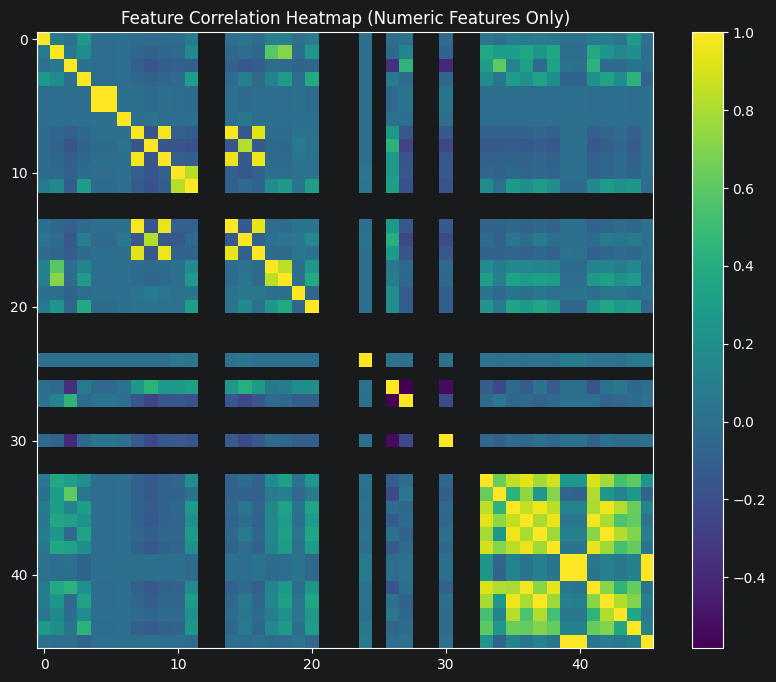

In [4]:

numeric_df = df.select_dtypes(include=['int64', 'float64'])
sample_df = numeric_df.sample(n=5000, random_state=42)

correlation_matrix = sample_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix)
plt.title("Feature Correlation Heatmap (Numeric Features Only)")
plt.colorbar()
plt.show()

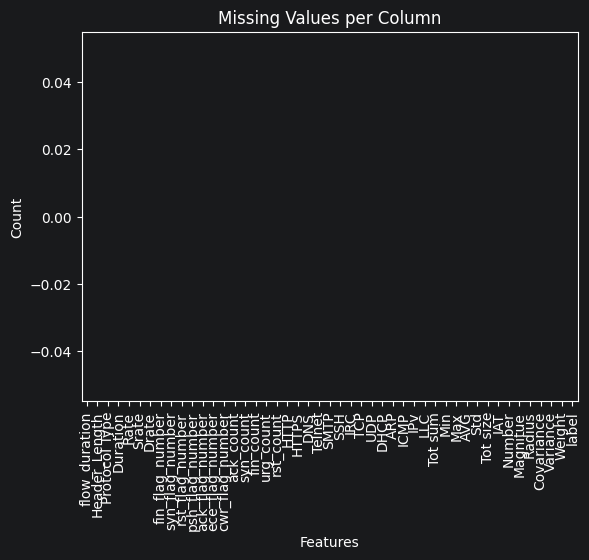

Total Missing Values: 0


In [5]:
missing = df.isnull().sum()

plt.figure()
missing.plot(kind='bar')
plt.title("Missing Values per Column")
plt.xlabel("Features")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

print("Total Missing Values:", missing.sum())

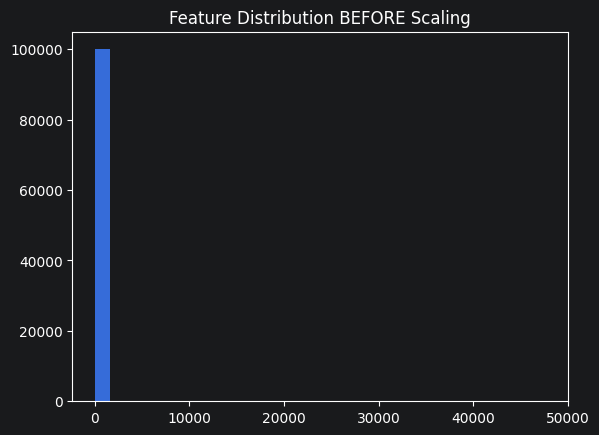

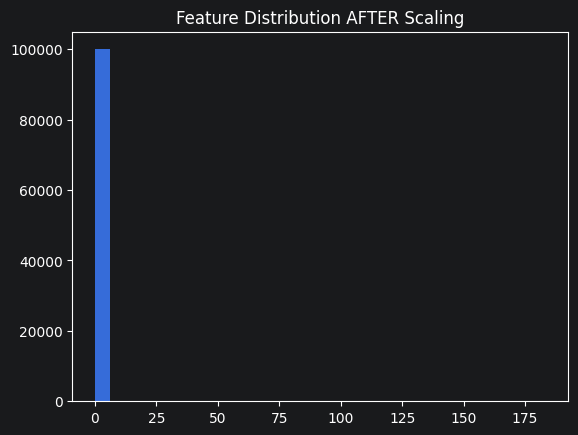

In [6]:


from sklearn.preprocessing import LabelEncoder, StandardScaler

target = "label"

X = df.drop(target, axis=1)
y = df[target]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

plt.figure()
plt.hist(X.iloc[:, 0], bins=30)
plt.title("Feature Distribution BEFORE Scaling")
plt.show()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


plt.figure()
plt.hist(X_scaled[:, 0], bins=30)
plt.title("Feature Distribution AFTER Scaling")
plt.show()

Train Shape: (80000, 46)
Test Shape: (20000, 46)


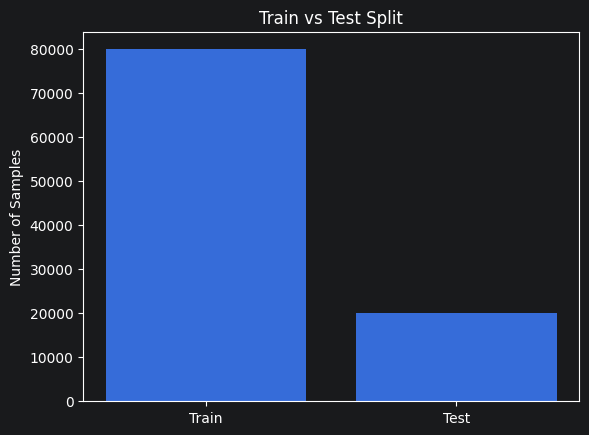

In [7]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)
sizes = [len(y_train), len(y_test)]
labels = ["Train", "Test"]

plt.figure()
plt.bar(labels, sizes)
plt.title("Train vs Test Split")
plt.ylabel("Number of Samples")
plt.show()

Logistic Regression Results:
Accuracy: 0.8161
Precision: 0.8288949899230865
Recall: 0.8161
F1 Score: 0.7850609086376147


/Users/sushantthakur/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


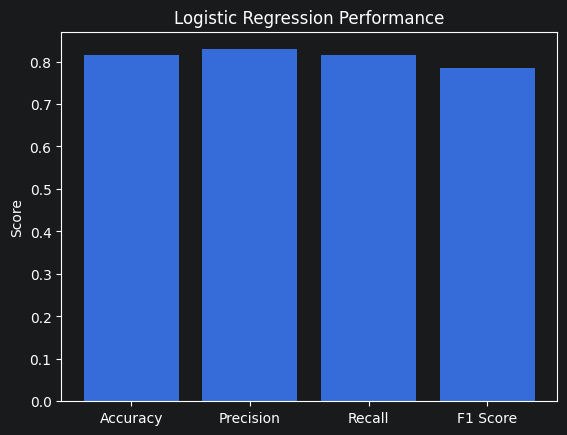

In [8]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

acc = accuracy_score(y_test, y_pred_lr)
prec = precision_score(y_test, y_pred_lr, average='weighted')
rec = recall_score(y_test, y_pred_lr, average='weighted')
f1 = f1_score(y_test, y_pred_lr, average='weighted')

print("Logistic Regression Results:")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

metrics = [acc, prec, rec, f1]
labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

plt.figure()
plt.bar(labels, metrics)
plt.title("Logistic Regression Performance")
plt.ylabel("Score")
plt.show()

Random Forest Results:
Accuracy: 0.99055
Precision: 0.9900529619357636
Recall: 0.99055
F1 Score: 0.9897340287977143


/Users/sushantthakur/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


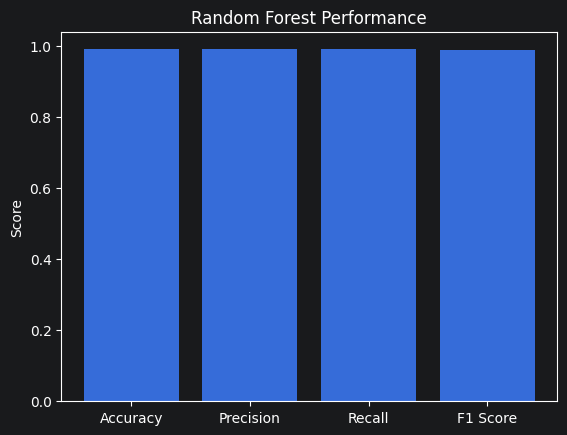

In [9]:
 
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

 
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print("Random Forest Results:")
print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)
print("F1 Score:", f1_rf)
 
metrics_rf = [acc_rf, prec_rf, rec_rf, f1_rf]
labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

plt.figure()
plt.bar(labels, metrics_rf)
plt.title("Random Forest Performance")
plt.ylabel("Score")
plt.show()

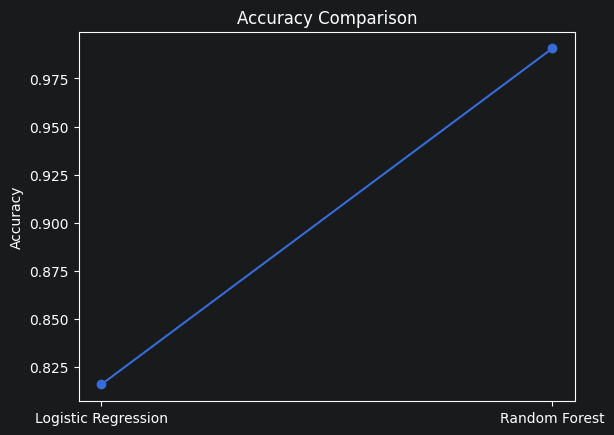

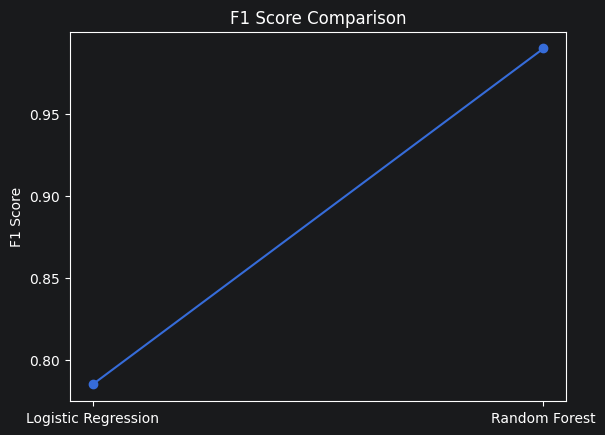

In [10]:
 
models = ["Logistic Regression", "Random Forest"]

accuracy = [acc, acc_rf]
precision = [prec, prec_rf]
recall = [rec, rec_rf]
f1_scores = [f1, f1_rf]

x = range(len(models))

# Accuracy Co 
plt.figure()
plt.plot(x, accuracy, marker='o')
plt.xticks(x, models)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()
 
plt.figure()
plt.plot(x, f1_scores, marker='o')
plt.xticks(x, models)
plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.show()

Neural Network (MLP) Results:
Accuracy: 0.97465
Precision: 0.9738937407974896
Recall: 0.97465
F1 Score: 0.9739273202667189


/Users/sushantthakur/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sushantthakur/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


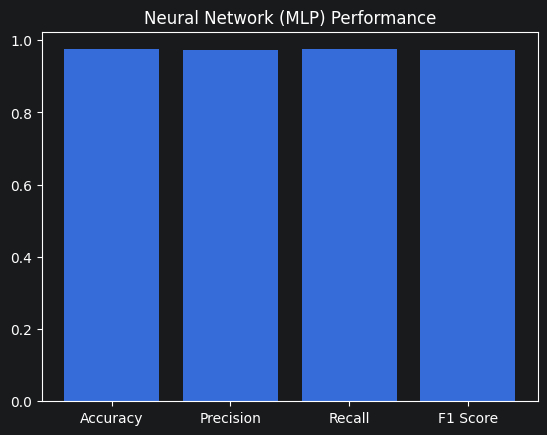

In [11]:
 
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100, random_state=42)
mlp.fit(X_train, y_train)

y_pred_nn = mlp.predict(X_test)
 
acc_nn = accuracy_score(y_test, y_pred_nn)
prec_nn = precision_score(y_test, y_pred_nn, average='weighted')
rec_nn = recall_score(y_test, y_pred_nn, average='weighted')
f1_nn = f1_score(y_test, y_pred_nn, average='weighted')

print("Neural Network (MLP) Results:")
print("Accuracy:", acc_nn)
print("Precision:", prec_nn)
print("Recall:", rec_nn)
print("F1 Score:", f1_nn)

# ===============================
# 📊 Visual
# ===============================
metrics_nn = [acc_nn, prec_nn, rec_nn, f1_nn]
labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

plt.figure()
plt.bar(labels, metrics_nn)
plt.title("Neural Network (MLP) Performance")
plt.show()

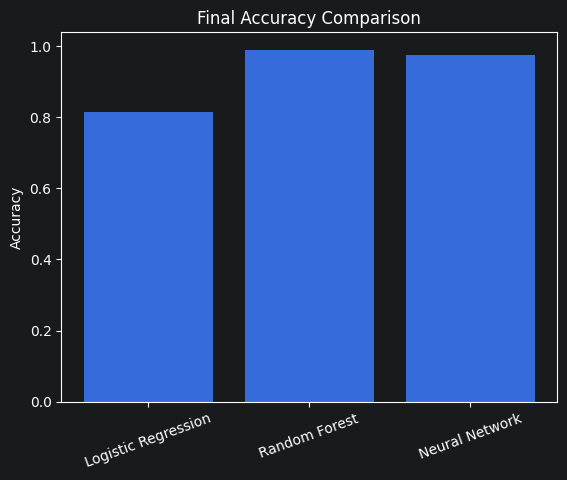

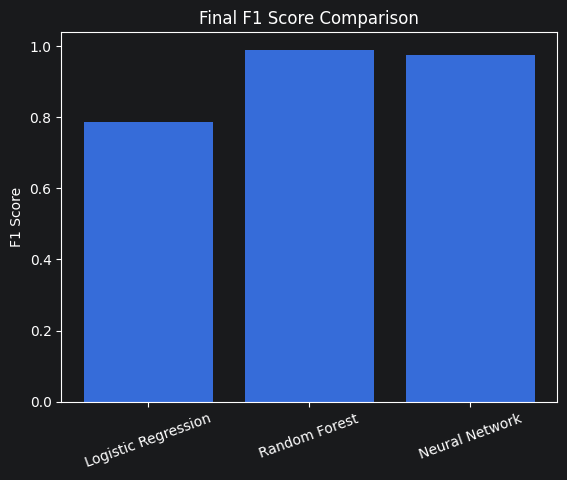

In [12]:
 
models = ["Logistic Regression", "Random Forest", "Neural Network"]

accuracy_all = [acc, acc_rf, acc_nn]
f1_all = [f1, f1_rf, f1_nn]

# Accuracy
plt.figure()
plt.bar(models, accuracy_all)
plt.title("Final Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

# F1 Score
plt.figure()
plt.bar(models, f1_all)
plt.title("Final F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=20)
plt.show()

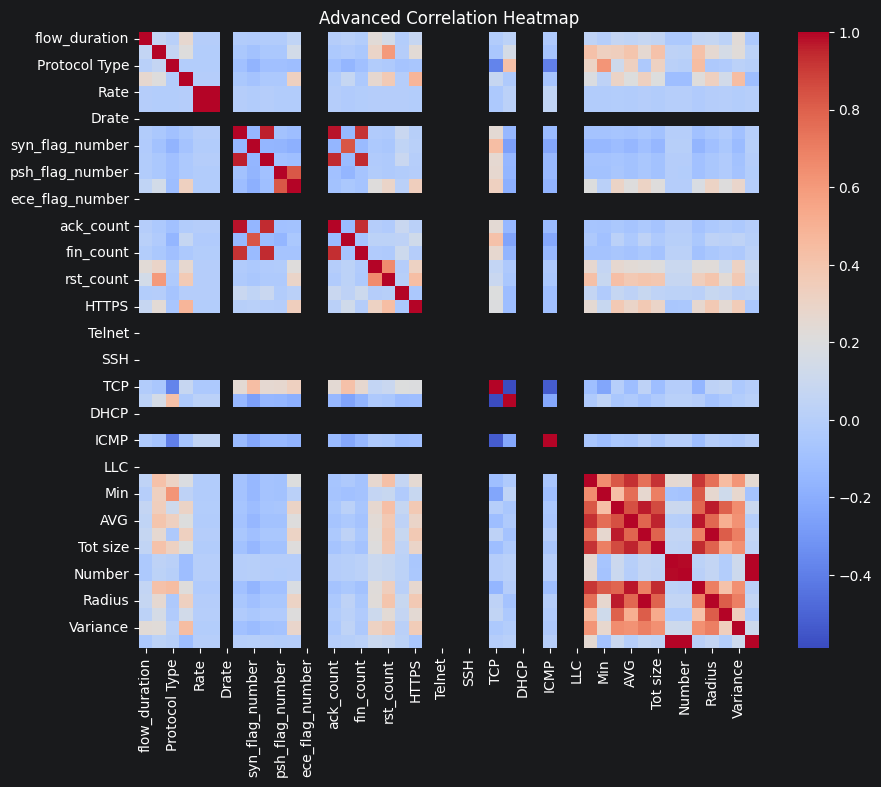

In [13]:
 
import seaborn as sns
 
sample_df = df.sample(n=2000, random_state=42)
 
numeric_df = sample_df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Advanced Correlation Heatmap")
plt.show()



In [14]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"

target = "label"
fig = px.histogram(df, x=target, title="Interactive Class Distribution")
fig.show()

import pandas as pd
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Neural Network"],
    "Accuracy": [0.8167, 0.9907, 0.9751]
})

fig = px.bar(results_df, x="Model", y="Accuracy",
             title="Model Accuracy Comparison",
             text="Accuracy")
fig.show()
